# Principal Component Identification
**Name:** C S Deeraj  
**Roll Number:** CH.SC.U4CSE24106

## Aim
To identify the variable with the strongest loading in the given principal component data.

## Requirements
- Python 3
- pandas

## Procedure
1. Store the given component loadings in a DataFrame.
2. Find the variable with the largest absolute loading in each component.
3. Identify the strongest loading across the complete table.

## Code

In [1]:
#CH.SC.U4CSE24106
import pandas as pd

### Enter the given dataset

In [2]:
data = {
    "Variable": ["Climate", "Housing", "Health", "Crime", "Transportation",
                 "Education", "Arts", "Recreation", "Economy"],
    "PC1": [0.190, 0.544, 0.782, 0.365, 0.585, 0.394, 0.985, 0.520, 0.142],
    "PC2": [0.017, 0.020, -0.605, 0.294, 0.085, -0.273, 0.126, 0.042, 0.150],
    "PC3": [0.207, 0.204, 0.144, 0.585, 0.234, 0.027, -0.111, 0.519, 0.239]
}

df = pd.DataFrame(data).set_index('Variable')
df

,PC1,PC2,PC3
Variable,,,
Climate,0.190,0.017,0.207
Housing,0.544,0.020,0.204
Health,0.782,-0.605,0.144
Crime,0.365,0.294,0.585
Transportation,0.585,0.085,0.234
Education,0.394,-0.273,0.027
Arts,0.985,0.126,-0.111
Recreation,0.520,0.042,0.519
Economy,0.142,0.150,0.239


### Find the strongest variable for each principal component

In [3]:
# Absolute values compare loading strength regardless of sign
abs_loadings = df.abs()
strongest_by_pc = abs_loadings.idxmax()
strongest_by_pc

,0
PC1,Arts
PC2,Health
PC3,Crime


### Identify the strongest loading overall

In [4]:
max_value = abs_loadings.max().max()
variable, component = abs_loadings.stack().idxmax()

print(f"Variable: {variable}")
print(f"Principal Component: {component}")
print(f"Loading: {df.loc[variable, component]:.3f}")

Variable: Arts
Principal Component: PC1
Loading: 0.985


## Output / Observation
- **PC1:** Arts has the strongest loading (0.985).
- **PC2:** Health has the strongest loading by magnitude (-0.605).
- **PC3:** Crime has the strongest loading (0.585).

## Result
**Arts is the variable with the strongest loading overall**, with a loading of **0.985 on PC1**. Therefore, Arts is most strongly associated with the first principal component in this table.

## Optional 1 — Visualize the loadings
A heatmap makes it easier to compare the loading strengths across components.

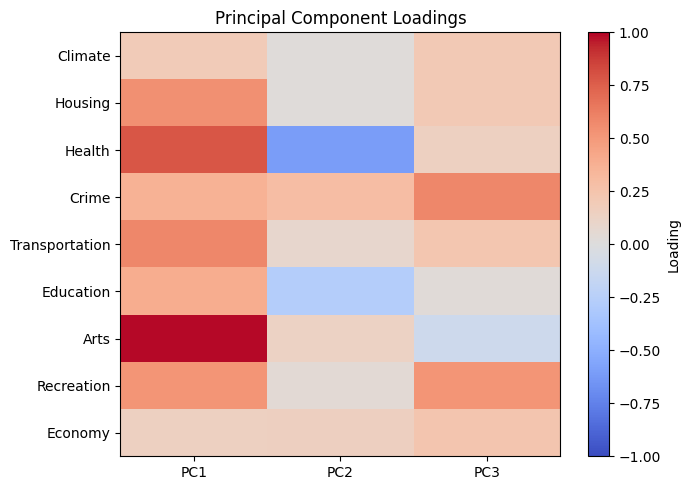

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.imshow(df, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Loading')
plt.xticks(range(len(df.columns)), df.columns)
plt.yticks(range(len(df.index)), df.index)
plt.title('Principal Component Loadings')
plt.tight_layout()
plt.show()

## Optional 2 — Display the strongest loading in each component

In [6]:
summary = pd.DataFrame({
    'Variable': strongest_by_pc,
    'Loading': [df.loc[strongest_by_pc[pc], pc] for pc in df.columns]
})
summary.index.name = 'Principal Component'
summary

,Variable,Loading
Principal Component,,
PC1,Arts,0.985
PC2,Health,-0.605
PC3,Crime,0.585
